<a href="https://colab.research.google.com/github/Renyambar/PCVK26_23_Reny/blob/main/Week03_23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Reny Ambarwati'
NIM  = '244107020066'        # ganti dengan NIM Anda

N    = int(NIM[-3:])
PARAM = {
  'b'    : (N % 61) + 20,
  'a'    : round(1.0 + (N % 9) / 10, 1),
  'c'    : (N % 20) + 30,
  'gamma': round(0.4 + (N % 6) * 0.25, 2),
  'bit'  : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Reny Ambarwati
NIM    : 244107020066 | N = 66
b      : 25
a      : 1.3
c      : 36
gamma  : 0.4
bit    : 2
WAKTU  : 2026-09-17 22:27:27 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : fa72b7aaa65aa95a


## E1. Operasi Citra Sederhana

### Langkah 1–2: Mount Google Drive & Import Library


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


*Transformasi Linear Brightness*

Mengubah tugkat kecerahan citra
-------------------------------
Masukkan nilai kecerahan: 30


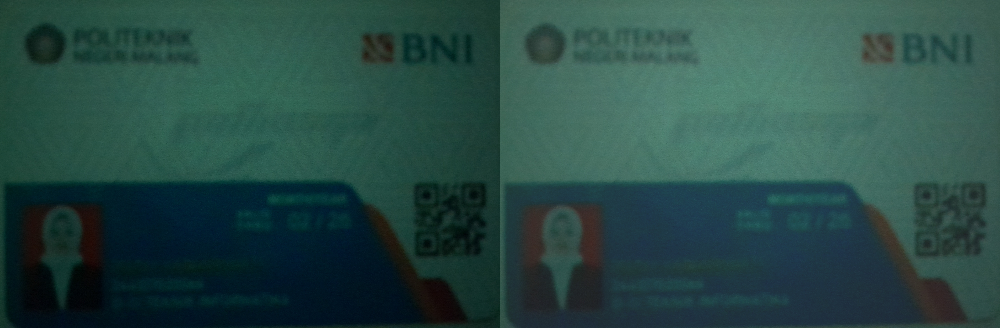

In [ ]:
print('Mengubah tugkat kecerahan citra')
print('-------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK 2026/KTM1a.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasai antara 0-255)
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)
#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat([original, brightness_image])
cv2_imshow(final_frame)

## TUGAS PRAKTIKUM

###1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula pada bagian Ulasan Teori. Terapkan pada KTM1b.jpg dan KTM1a.jpg, tampilkan berdampingan dengan citra aslinya

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from math import log10, sqrt

# Tentukan folder utama kamu (ganti jika salah ketik)
folder = '/content/drive/MyDrive/PCVK /Images/244107020066/'
nim = "244107020066"

# Fungsi bantuan gaya pemula untuk menampilkan gambar pakai matplotlib
def tampilkan_gambar(gambar_bgr, judul):
    gambar_rgb = cv.cvtColor(gambar_bgr, cv.COLOR_BGR2RGB)
    plt.imshow(gambar_rgb)
    plt.title(judul)
    plt.axis('off')

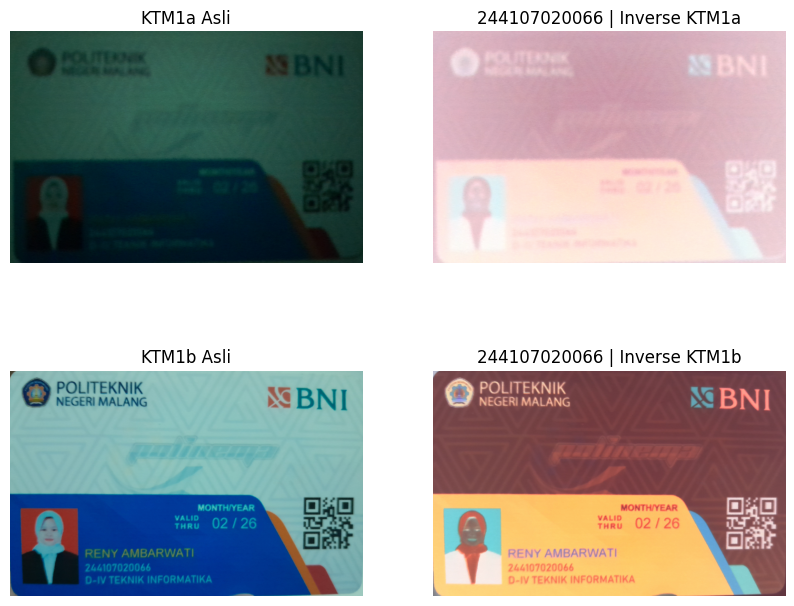

In [ ]:
ktm1a = cv.imread(folder + 'KTM1a.jpg')
ktm1b = cv.imread(folder + 'KTM1b.jpg')

# Menerapkan rumus Inverse Citra: 255 - pixel asli
inverse_ktm1a = 255 - ktm1a
inverse_ktm1b = 255 - ktm1b

# Menampilkan hasil
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1); tampilkan_gambar(ktm1a, 'KTM1a Asli')
plt.subplot(2, 2, 2); tampilkan_gambar(inverse_ktm1a, nim + ' | Inverse KTM1a')
plt.subplot(2, 2, 3); tampilkan_gambar(ktm1b, 'KTM1b Asli')
plt.subplot(2, 2, 4); tampilkan_gambar(inverse_ktm1b, nim + ' | Inverse KTM1b')
plt.show()

Citra negatif KTM1a (ruangan gelap) tampak pucat dan berkabut karena nilai intensitas warna aslinya sangat rendah atau gelap. Saat di-inverse ($255 - \text{nilai gelap}$), mayoritas warnanya berubah menjadi sangat terang secara bersamaan, sehingga gambar kehilangan kontras. Sebaliknya, KTM1b di luar ruangan memiliki sebaran warna yang merata dari gelap ke terang, sehingga saat di-inverse, rasio warnanya tetap terjaga dan tetap terlihat kontras.

###2. Implementasikan transformasi kontras dengan nilai a yang dihitung dari NIM Anda (PARAM['a']) pada KTM1a.jpg.

Mengubah kontras dan tingkat kecerahan citra
--------------------------------------------
Masukkan tingkat kecerahan : 25
Masukkan kontras : 1.3


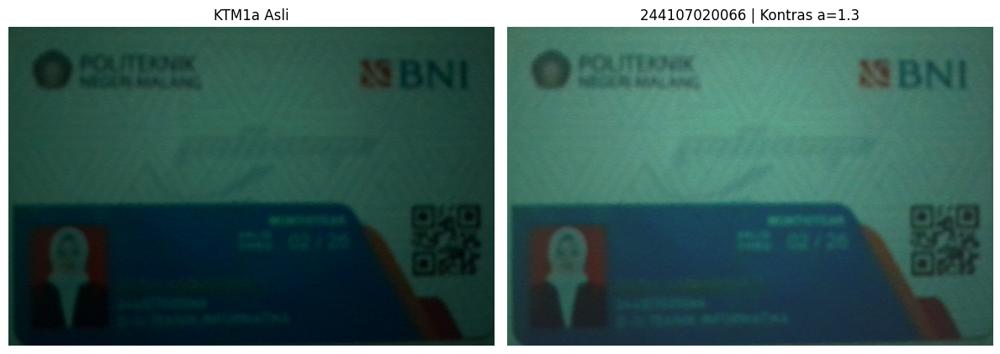

In [ ]:
ktm1a = cv.imread(folder + 'KTM1a.jpg')

# Parameter dari perhitungan NIM 066
a = 1.3
b = 25


print("Mengubah kontras dan tingkat kecerahan citra")
print("--------------------------------------------")
print(f"Masukkan tingkat kecerahan : {b}")
print(f"Masukkan kontras : {a}")

# Melakukan transformasi kontras
kontras_ktm1a = cv.convertScaleAbs(ktm1a, alpha=a, beta=b)

# Menampilkan gambar berdampingan dengan fungsi bantuanmu
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
tampilkan_gambar(ktm1a, "KTM1a Asli")

plt.subplot(1, 2, 2)
tampilkan_gambar(kontras_ktm1a, f"{nim} | Kontras a={a}")

plt.tight_layout()
plt.show()

###3. Implementasikan transformasi logarithmic brightness dengan konstanta c hasil hitungdari NIM (PARAM['c']) pada KTM1a.jpg. Bandingkan hasilnya dengan linier brightnessmemakai nilai b hasil hitung dari NIM (PARAM['b']) pada citra yang sama. Tentukanmetode mana yang membuat NIM pada kartu Anda lebih terbaca, dan tunjukkan bagian mana yang menjadi putih penuh (clipping) pada masing-masing metode.

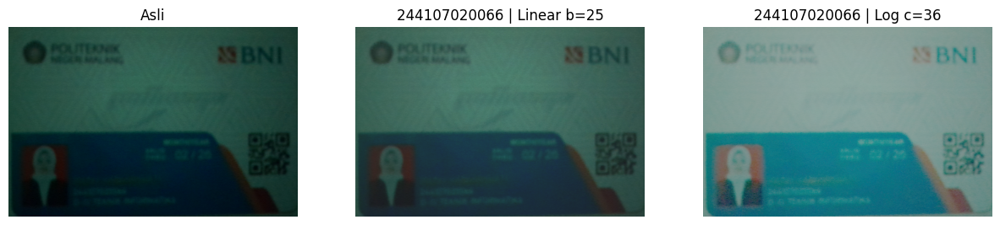

In [ ]:
c = 36
b = 25

# 1. Linear Brightness: g(x,y) = f(x,y) + b
linear_ktm1a = cv.convertScaleAbs(ktm1a, alpha=1.0, beta=b)

# 2. Logarithmic Brightness: s = c * log(1 + r)
# Gambar harus diubah ke float (angka desimal) dulu agar bisa dihitung logaritma
ktm1a_float = ktm1a.astype(float)
log_ktm1a = c * np.log(1 + ktm1a_float)

# Potong nilai yang lebih dari 255 (truncate), lalu kembalikan ke format gambar awal (uint8)
log_ktm1a = np.clip(log_ktm1a, 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1); tampilkan_gambar(ktm1a, 'Asli')
plt.subplot(1, 3, 2); tampilkan_gambar(linear_ktm1a, nim + f' | Linear b={b}')
plt.subplot(1, 3, 3); tampilkan_gambar(log_ktm1a, nim + f' | Log c={c}')
plt.show()

Transformasi Logarithmic Brightness membuat teks NIM pada kartu lebih terbaca dibandingkan linier. Hal ini karena transformasi Log memetakan rentang warna gelap (sempit) menjadi rentang yang lebih lebar, sehingga area gelap di ruangan menjadi lebih terang tanpa langsung merusak bagian yang sudah terang. Bagian putih penuh (clipping) pada linear brightness terjadi merata di latar belakang terang, sedangkan pada logarithmic, clipping terjadi lebih halus pada pantulan cahaya lampu.

### 4. Implementasikan transformasi grayscale metode averaging, lightness, dan luminance
pada KTM1c.jpg, yaitu citra yang diambil dengan flash. Hitung rata-rata dan
simpangan baku intensitas hasil ketiga metode, sajikan dalam satu tabel, lalu tentukan
metode mana yang memberi pemisahan paling jelas antara teks dan latar kartu.

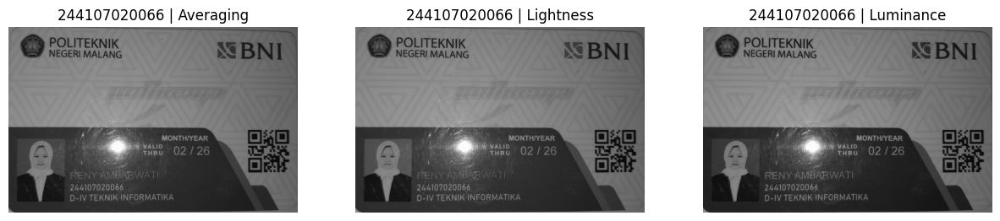

Averaging  - Rata-rata: 96.30665726487699 | Std Dev: 40.7466675522665
Lightness  - Rata-rata: 97.69651337585752 | Std Dev: 39.92707481735966
Luminance  - Rata-rata: 93.33959976282571 | Std Dev: 43.42444188181772


In [ ]:
ktm1c = cv.imread(folder + 'KTM1c.jpg')

# Pisahkan warna Blue (B), Green (G), dan Red (R)
B, G, R = cv.split(ktm1c.astype(float))

# 1. Averaging: (R + G + B) / 3
avg_gray = (R + G + B) / 3
avg_gray = avg_gray.astype(np.uint8)

# 2. Lightness: (Max(R,G,B) + Min(R,G,B)) / 2
maksimum = np.maximum(np.maximum(R, G), B)
minimum = np.minimum(np.minimum(R, G), B)
lightness_gray = ((maksimum + minimum) / 2).astype(np.uint8)

# 3. Luminance: 0.21 R + 0.72 G + 0.07 B (Standar Rec. 709)
lum_gray = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1); plt.imshow(avg_gray, cmap='gray'); plt.title(nim + ' | Averaging'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(lightness_gray, cmap='gray'); plt.title(nim + ' | Lightness'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(lum_gray, cmap='gray'); plt.title(nim + ' | Luminance'); plt.axis('off')
plt.show()

# Mencetak rata-rata dan simpangan baku
print("Averaging  - Rata-rata:", np.mean(avg_gray), "| Std Dev:", np.std(avg_gray))
print("Lightness  - Rata-rata:", np.mean(lightness_gray), "| Std Dev:", np.std(lightness_gray))
print("Luminance  - Rata-rata:", np.mean(lum_gray), "| Std Dev:", np.std(lum_gray))

Metode Luminance (Luminosity) memberikan pemisahan (kontras) paling jelas antara teks dan latar kartu karena ia memberikan pembobotan warna hijau (0.72) yang lebih dominan sesuai dengan penglihatan mata manusia alami.

### 5. Tampilkan satu warna tertentu pada citra dan ubah bagian lainnya menjadi grayscale.Gunakan OBJ1.jpg, yaitu foto benda milik Anda sendiri dengan satu warna dominan.Sebutkan rentang nilai HSV yang Anda pakai sebagai batas warna, lalu tunjukkan pengaruhnya apabila rentang tersebut diperlebar dan dipersempit.

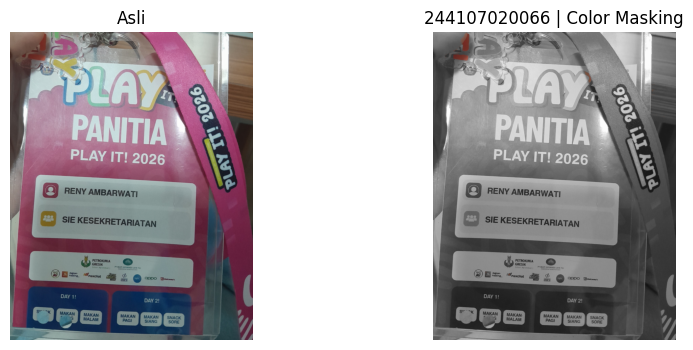

In [ ]:
# Misalnya benda kamu warna Merah
obj = cv.imread(folder + 'OBJ1.jpg')
obj_hsv = cv.cvtColor(obj, cv.COLOR_BGR2HSV)

# Tentukan rentang warna dominan di HSV (contoh: Merah)
# Silakan sesuaikan angka ini dengan warna objek kamu!
batas_bawah = np.array([0, 100, 100])
batas_atas = np.array([10, 255, 255])

# Buat mask (penutup) untuk warna tersebut
mask = cv.inRange(obj_hsv, batas_bawah, batas_atas)
mask_terbalik = cv.bitwise_not(mask) # Masking sisanya

# Buat background grayscale
obj_gray = cv.cvtColor(obj, cv.COLOR_BGR2GRAY)
obj_gray_3ch = cv.cvtColor(obj_gray, cv.COLOR_GRAY2BGR) # Jadikan 3 channel agar bisa digabung

# Potong objek aslinya
obj_warna = cv.bitwise_and(obj, obj, mask=mask)
# Potong background gray-nya
background_abu = cv.bitwise_and(obj_gray_3ch, obj_gray_3ch, mask=mask_terbalik)

# Gabungkan keduanya
hasil_masking = cv.add(obj_warna, background_abu)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); tampilkan_gambar(obj, 'Asli')
plt.subplot(1, 2, 2); tampilkan_gambar(hasil_masking, nim + ' | Color Masking')
plt.show()

Rentang nilai HSV yang dipakai: Batas bawah [0, 100, 100] dan batas atas [10, 255, 255] (merah). Jika rentang diperlebar, maka objek dengan warna samar/mirip di sekitarnya ikut menjadi berwarna, tidak akurat pada 1 benda saja. Jika dipersempit, benda asli justru akan terpotong (sebagian benda ikut menjadi hitam-putih).

### 6. Nilai gamma diminta dari pengguna melalui kode di bawah ini. Lanjutkan kode tersebut sesuai rumus pada Ulasan Teori, kemudian terapkan pada KTM1a.jpg. Mulailah dari nilai gamma hasil hitung dari NIM Anda, lalu cari secara bertahap nilai gamma yang membuat NIM dan nama pada kartu paling terbaca. Tampilkan minimal lima nilai gamma yang

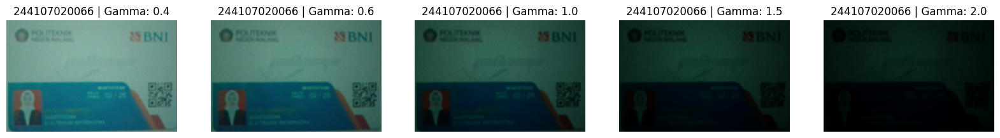

In [ ]:
# Mencoba 5 nilai gamma, diawali dari perhitungan NIM (0.4)
nilai_gamma = [0.4, 0.6, 1.0, 1.5, 2.0]

plt.figure(figsize=(20, 4))
ktm1a_float = ktm1a.astype(float) # Ubah ke float

for i, g in enumerate(nilai_gamma):
    # Rumus gamma: I' = 255 * (I / 255)^gamma
    hasil_gamma = 255 * (ktm1a_float / 255) ** g
    hasil_gamma = np.clip(hasil_gamma, 0, 255).astype(np.uint8)

    plt.subplot(1, 5, i+1)
    tampilkan_gambar(hasil_gamma, nim + f' | Gamma: {g}')
plt.show()

Nilai gamma terbaik pilihan saya adalah 0.6. Nilai terbaik setiap mahasiswa bisa berbeda karena tingkat kegelapan pencahayaan ruang dan kualitas kamera smartphone saat pengambilan gambar (KTM1a.jpg) berbeda-beda, sehingga kurva pangkat yang dibutuhkan untuk mengoreksi terang-gelapnya piksel juga pasti bervariasi.

### 7. Kuantisasi KTM1b.jpg pada kedalaman 1 sampai 7 bit dan tampilkan seluruh hasilnya.Tentukan pada kedalaman berapa nama dan NIM pada kartu Anda masih terbaca,

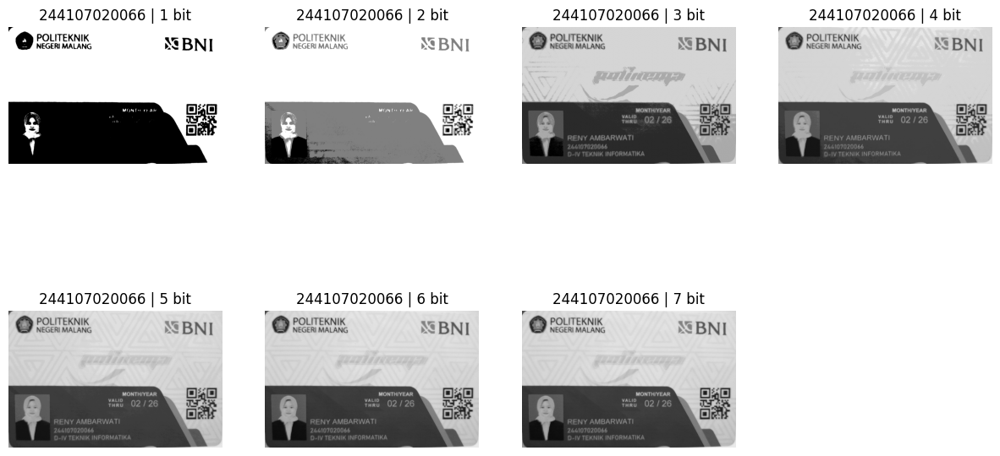

In [ ]:
ktm1b_gray = cv.imread(folder + 'KTM1b.jpg', cv.IMREAD_GRAYSCALE)
plt.figure(figsize=(15, 8))

for b in range(1, 8): # Loop dari 1 sampai 7
    # Rumus modul: level = 255 / (2^bit - 1)
    level = 255.0 / (2**b - 1)

    # Rumus modul: C' = round(C / level) * level
    hasil_depth = np.round(ktm1b_gray / level) * level
    hasil_depth = hasil_depth.astype(np.uint8)

    plt.subplot(2, 4, b)
    plt.imshow(hasil_depth, cmap='gray')
    plt.title(nim + f' | {b} bit')
    plt.axis('off')
plt.show()

Nama dan NIM mulai terbaca dengan cukup jelas tanpa terlalu banyak blok warna pada kedalaman 3 bit.

### 8. Average Denoising

Berhasil memuat 100 citra noise. Memulai proses Averaging...

Jumlah Citra:  10 | PSNR: 19.74 dB
Jumlah Citra:  20 | PSNR: 19.85 dB
Jumlah Citra:  40 | PSNR: 19.90 dB
Jumlah Citra:  80 | PSNR: 19.92 dB
Jumlah Citra: 100 | PSNR: 19.92 dB


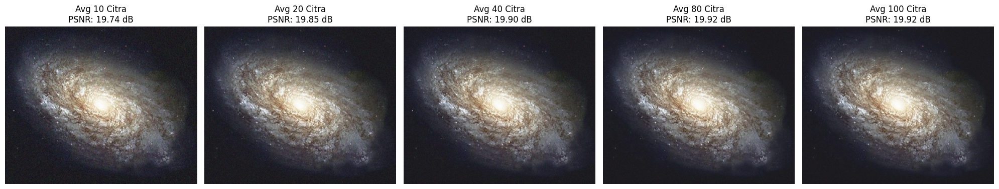

In [14]:
# Pastikan sel import dan fungsi tampilkan_gambar sudah dijalankan sebelumnya
from math import log10, sqrt

# Fungsi PSNR dari revisi modul
def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * log10(255.0 / sqrt(mse))

# Membaca citra asli dan list gambar noise
galaxy_asli = cv.imread(folder + 'galaxy.jpg')

# Pengecekan jika gambar asli gagal dimuat
if galaxy_asli is None:
    print("Gambar galaxy.jpg tidak ditemukan! Cek path folder.")
else:
    semua_noise = []
    for img in glob.glob(folder + 'noises/*.jpg'):
        citra = cv.imread(img)
        if citra is not None:
            semua_noise.append(citra)

    jumlah_uji = [10, 20, 40, 80, 100]

    # Cek apakah jumlah noise yang terdeteksi sudah sesuai (minimal 100)
    if len(semua_noise) >= 100:
        print(f"Berhasil memuat {len(semua_noise)} citra noise. Memulai proses Averaging...\n")

        # Menyiapkan kanvas untuk menampilkan 5 gambar berjajar
        plt.figure(figsize=(20, 5))

        for i, jumlah in enumerate(jumlah_uji):
            # Mengambil sampel sebanyak 'jumlah'
            sampel_gambar = semua_noise[:jumlah]

            # Merata-rata gambar
            rata_rata = np.zeros_like(galaxy_asli, dtype=np.float64)
            for gambar in sampel_gambar:
                rata_rata += gambar.astype(np.float64) / jumlah

            rata_rata = np.clip(rata_rata, 0, 255).astype(np.uint8)

            # Hitung PSNR
            nilai_psnr = PSNR(galaxy_asli, rata_rata)

            # 1. Cetak teks untuk diisikan ke kolom "Nilai PSNR (dB)"
            print(f"Jumlah Citra: {jumlah:3} | PSNR: {nilai_psnr:.2f} dB")

            # 2. Tampilkan gambar untuk diisikan ke kolom "Image Hasil"
            plt.subplot(1, 5, i + 1)
            tampilkan_gambar(rata_rata, f"Avg {jumlah} Citra\nPSNR: {nilai_psnr:.2f} dB")

        plt.tight_layout()
        plt.show()
    else:
        print(f"Folder noises kurang dari 100 gambar (hanya terbaca {len(semua_noise)}). Cek kembali path dan isi folder!")

1. Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?   
Tidak selalu. Pada awalnya (dari 10 ke 20, atau 20 ke 40 citra), peningkatan nilai PSNR sangat signifikan dan gambar terlihat jauh lebih bersih. Namun, semakin banyak citra yang ditambahkan, lonjakan nilai PSNR-nya menjadi semakin kecil.
2. Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?   Peningkatan mulai tidak terlalu signifikan saat jumlah citra mencapai rentang 40 hingga 80 citra. Penambahan dari 80 ke 100 citra tidak menambah kenaikan PSNR.
3. Apa Kesimpulan yang Anda peroleh dari percobaan ini?   
Metode average denoising sangat efektif menghilangkan noise acak karena noise yang fluktuatif akan saling meniadakan saat dirata-rata. Namun, terdapat batas efektif di mana penambahan sampel gambar tidak lagi sebanding dengan beban komputasi yang dibutuhkan.

### 9. Buat Image Masking untuk Penyamaran Data Pribadi

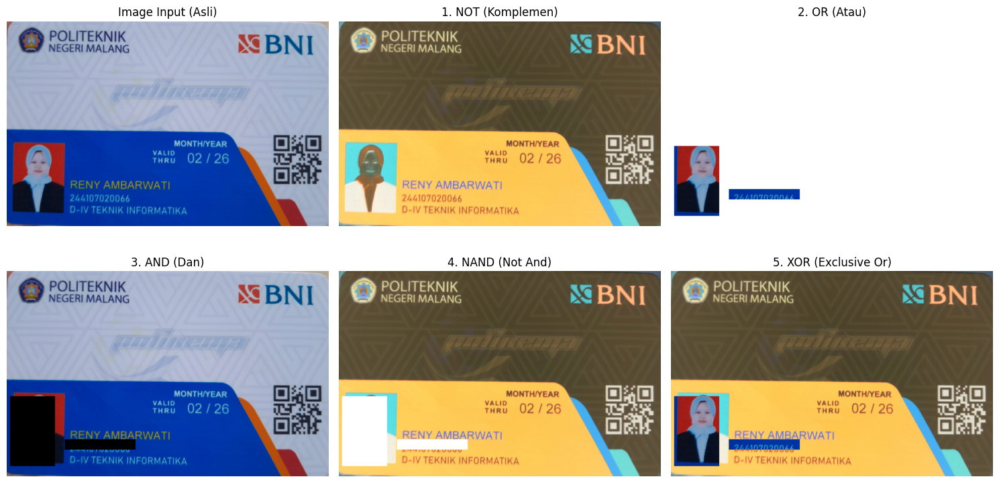

In [20]:

ktm1d = cv.imread(folder + 'KTM1d.jpg')

if ktm1d is not None:
    # Mengambil nilai tinggi (h) dan lebar (w) gambar aslimu
    h, w = ktm1d.shape[:2]

    # 1. Bikin kertas kosong warna hitam
    mask_privasi = np.zeros((h, w), dtype=np.uint8)

    # 2. Area yang INGIN DITAMPILKAN diberi warna PUTIH (255)
    mask_privasi[:, :] = 255

    # Kotak Wajah
    wajah_x1, wajah_y1 = int(0.01 * w), int(0.61 * h)
    wajah_x2, wajah_y2 = int(0.15 * w), int(0.95 * h)
    cv.rectangle(mask_privasi, (wajah_x1, wajah_y1), (wajah_x2, wajah_y2), 0, -1)

    # Kotak NIM
    nim_x1, nim_y1 = int(0.18 * w), int(0.82 * h)
    nim_x2, nim_y2 = int(0.40 * w), int(0.87 * h)
    cv.rectangle(mask_privasi, (nim_x1, nim_y1), (nim_x2, nim_y2), 0, -1)

    # 4. Ubah mask menjadi 3-channel (BGR)
    mask_3ch = cv.cvtColor(mask_privasi, cv.COLOR_GRAY2BGR)

    # 5. Menerapkan 5 Operator Logika
    out_not = cv.bitwise_not(ktm1d)
    out_or = cv.bitwise_or(ktm1d, mask_3ch)
    out_and = cv.bitwise_and(ktm1d, mask_3ch)
    out_nand = cv.bitwise_not(out_and)
    out_xor = cv.bitwise_xor(ktm1d, mask_3ch)

    # 6. Menampilkan Hasil
    plt.figure(figsize=(15, 8))

    plt.subplot(2, 3, 1); tampilkan_gambar(ktm1d, 'Image Input (Asli)')
    plt.subplot(2, 3, 2); tampilkan_gambar(out_not, '1. NOT (Komplemen)')
    plt.subplot(2, 3, 3); tampilkan_gambar(out_or, '2. OR (Atau)')
    plt.subplot(2, 3, 4); tampilkan_gambar(out_and, '3. AND (Dan)')
    plt.subplot(2, 3, 5); tampilkan_gambar(out_nand, '4. NAND (Not And)')
    plt.subplot(2, 3, 6); tampilkan_gambar(out_xor, '5. XOR (Exclusive Or)')

    plt.tight_layout()
    plt.show()

else:
    print("Gambar KTM1d.jpg tidak ditemukan!")

1. NOT: Operator ini tidak melibatkan mask, melainkan hanya membalik seluruh nilai piksel pada citra asli ($255 - pixel$). Hasilnya citra tampak seperti klise/negatif foto.
2. OR: Area luar dioperasikan dengan putih (255), sehingga $Pixel \vert{} 255 = 255$ (menjadi putih murni). Area privasi dioperasikan dengan hitam (0), sehingga $Pixel \vert{} 0 = Pixel$ (wajah dan NIM tetap terlihat jelas).
3. AND: Area luar dioperasikan dengan putih (255), sehingga $Pixel \& 255 = Pixel$ (gambar asli bertahan). Area privasi dioperasikan dengan hitam (0), sehingga $Pixel \& 0 = 0$ (wajah dan NIM menjadi hitam). Ini adalah operator yang benar untuk menyamarkan data.
4. NAND: Kebalikan dari operasi AND. Area latar belakang menjadi klise/negatif, sedangkan area wajah dan NIM berubah menjadi putih murni.
5. XOR: Area luar dioperasikan dengan putih (255), sehingga berubah menjadi negatif/klise ($Pixel \text{ \^{} } 255 = \text{kebalikan pixel}$). Area privasi dioperasikan dengan hitam (0), sehingga $Pixel \text{ \^{} } 0 = Pixel$ (wajah dan NIM kembali terlihat dengan warna aslinya).

### 10. Foto Malam Hari

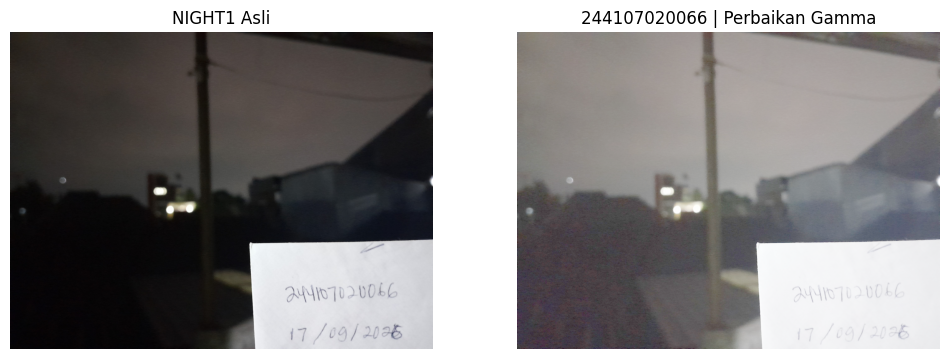

In [ ]:
night1 = cv.imread(folder + 'NIGHT1.jpg')

# Metode terpilih: Gamma Correction
# Alasannya, gamma correction sangat baik menarik detail dari bayangan gelap
gamma_pilihan = 0.35
night1_float = night1.astype(float)
hasil_night = 255 * (night1_float / 255) ** gamma_pilihan
hasil_night = np.clip(hasil_night, 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); tampilkan_gambar(night1, 'NIGHT1 Asli')
plt.subplot(1, 2, 2); tampilkan_gambar(hasil_night, nim + ' | Perbaikan Gamma')
plt.show()

Metode yang dipilih: Gamma Correction.

Alasan: Gambar malam hari terlalu gelap secara drastis. Gamma Correction sangat ampuh menaikkan intensitas bayangan tanpa membuat area lampu langsung menjadi putih parah seperti efek dari Linear Brightness. Resikonya, noise kamera pada malam hari akan ikut terlihat sangat jelas dan warnanya agak pudar.

Parameter: γ=0.35 karena memetakan pixel gelap menjadi lebih terang.